In [7]:

# Implement Boston housing price prediction problem by Linear
# regression using Deep Neural network. Use Boston House price prediction dataset.
import numpy as np
import pandas as pd

In [9]:
from sklearn.datasets import fetch_california_housing

boston = fetch_california_housing()



ValueError: All ufuncs must have type `numpy.ufunc`. Received (<ufunc 'sph_legendre_p'>, <ufunc 'sph_legendre_p'>, <ufunc 'sph_legendre_p'>)

In [ ]:
# Converting the data into pandas dataframe
data = pd.DataFrame(boston.data)

In [ ]:
data.head()

In [ ]:
# Adding the feature names to the dataframe
data.columns = boston.feature_names

In [24]:
# Adding the target variable to the dataset
data['PRICE'] = boston.target

In [25]:
# Looking at the data with names and target variable
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [26]:
# Checking the null values in the dataset
data.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64

In [27]:
# Checking the statistics of the data
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [29]:
x = boston.data
y = boston.target

In [30]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain, ytest = train_test_split(x,y, test_size=0.2, random_state= 42)
print("xtrain shape:", xtrain.shape)
print("xtest shape:", xtest.shape)
print("ytrain shape:", ytrain.shape)
print("ytest shape:", ytest.shape)

xtrain shape: (16512, 8)
xtest shape: (4128, 8)
ytrain shape: (16512,)
ytest shape: (4128,)


In [31]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(xtrain, ytrain)
y_pred = lr.predict(xtest)

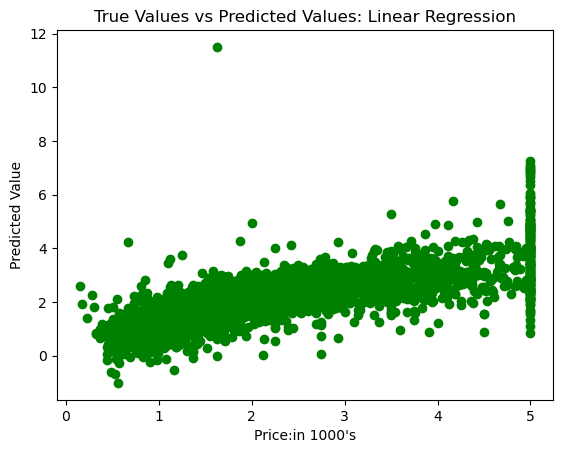

In [32]:
import matplotlib.pyplot as plt
plt.scatter(ytest, y_pred, c = 'green')
plt.xlabel("Price:in 1000's")
plt.ylabel("Predicted Value")
plt.title("True Values vs Predicted Values: Linear Regression")
plt.show()

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(ytest, y_pred)
mae = mean_absolute_error(ytest, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

Mean Squared Error: 0.5558915986952424
Mean Absolute Error: 0.533200130495698


In [34]:
!pip install tensorflow

In [35]:
# Creating the neural network model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
model = Sequential()
model.add(Dense(128,activation = 'relu',input_dim =8))
model.add(Dense(64,activation = 'relu'))
model.add(Dense(32,activation = 'relu'))
model.add(Dense(16,activation = 'relu'))
model.add(Dense(1))
model.compile(optimizer = 'adam',loss = 'mean_squared_error')

C:\Users\DELL-PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.fit(xtrain, ytrain, epochs=100)

Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 77.8699 
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.2359
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.6222
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1637
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.0971
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.4916
Epoch 7/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.9308
Epoch 8/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.7369
Epoch 9/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.9751
Epoch 10/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8411
Epoch 11/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.8793
Epoch 12/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.3619
Epoch 13/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.9283
Epoch 14/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8821
Epoch 15/100
516/516 ━━━━━━━━━━━━━━━━━━━━

In [38]:
y_pred = model.predict(X_test)

NameError: name 'X_test' is not defined

In [ ]:
# Predicting RMSE the Test set results
from sklearn.metrics import mean_squared_error
rmse = (np.sqrt(mean_squared_error(y_test, y_pred)))
print(rmse)